# Instalação de depedencias e configuração

In [1]:
!pip install numpy matplotlib scikit-learn pandas
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 65.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 62.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import pandas as pd
import pickle

In [3]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('dark_background')

# Dataset

In [4]:
#data set
x, y = datasets.make_moons(n_samples=500, noise=0.05)

In [5]:
print(f'{x.shape = }, {y.shape = }')

x.shape = (500, 2), y.shape = (500,)


In [6]:
pd.DataFrame({'x_1': x[:, 0], 'x_2': x[:, 1], 'y': y})

,x_1,x_2,y
0,-0.245384,0.933771,0
1,0.623298,-0.364462,1
2,1.048326,-0.495588,1
3,0.949842,0.133264,0
4,1.227747,-0.555254,1
...,...,...,...
495,0.455223,-0.340030,1
496,1.998617,0.471075,1
497,0.172241,-0.005876,1
498,1.284957,-0.465695,1


In [7]:
unique = np.unique(y, return_counts=True)
for label, qt_label in zip(unique[0], unique[1]):
    print(f'label: {label}\t Counts: {qt_label}')

label: 0	 Counts: 250
label: 1	 Counts: 250


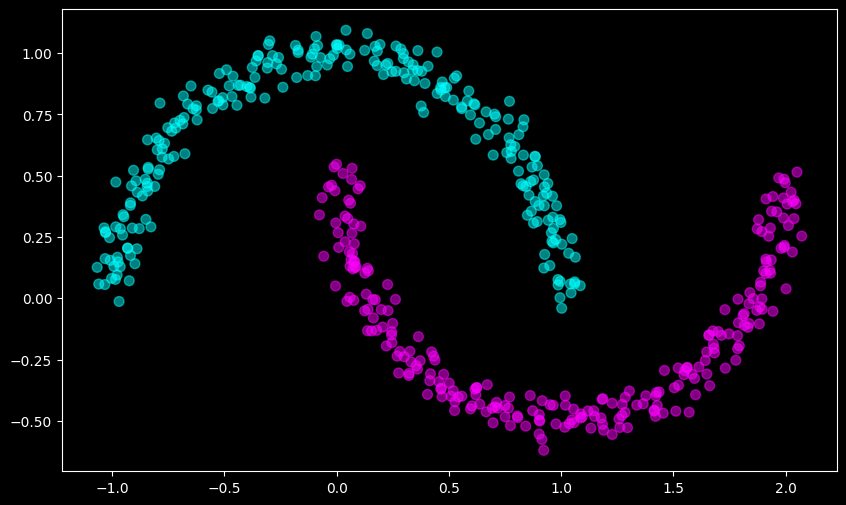

In [8]:
plt.scatter(x[:, 0], x[:, 1], c=y, s=50, alpha=0.5, cmap='cool')

# Modelo

In [9]:
class NnModel:
    def __init__(self, x: np.ndarray, y: np.ndarray, hidden_neurons: int = 10, output_neurons: int = 2):
        np.random.seed(8)
        self.x = x
        self.y = y
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.input_neurons = self.x.shape[1]

        # inicializa os pesos e bias
        # Xavier inicialization -> variação uniforme dos pesos
        self.W1 = np.random.randn(self.input_neurons, self.hidden_neurons) / np.sqrt(self.input_neurons)
        self.B1 = np.zeros((1, self.hidden_neurons))
        self.W2 = np.random.randn(self.hidden_neurons, self.output_neurons) / np.sqrt(self.hidden_neurons)
        self.B2 = np.zeros((1, self.output_neurons))
        self.model_dict = {'W1': self.W1, 'B1': self.B1, 'W2': self.W2, 'B2': self.B2}
        self.z1 = 0
        self.f1 = 0

    def forward(self, x: np.ndarray) -> np.ndarray:
        # Equação da reta
        self.z1 = x.dot(self.W1) + self.B1

        # Função de ativação (1)
        self.f1 = np.tanh(self.z1)

        # Equação da reta (2)
        z2 = self.f1.dot(self.W2) + self.B2

        # Softmax
        exp_values = np.exp(z2)
        softmax = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        return softmax

    def loss(self, softmax: np.ndarray) -> np.ndarray:
        # Cross Entropy
        predictions = np.zeros(self.y.shape[0])
        for i, correct_index in enumerate(self.y):
            predicted = softmax[i][correct_index]
            predictions[i] = predicted
        log_prob = -np.log(predicted)
        return log_prob/self.y.shape[0]


    def backpropagation(self, softmax: np.ndarray, learning_rate: float) -> None:

        pass

    def fit(self):
        pass

In [10]:
modelo = NnModel(x, y, hidden_neurons=10, output_neurons=2)
softmax = modelo.forward(x)
modelo.loss(softmax)

np.float64(0.0021940147341172954)